In [44]:
import kagglehub
import pandas as pd
import numpy as np
import os

path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print(" Path to dataset files:", path)

files = [
'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
'Monday-WorkingHours.pcap_ISCX.csv',
'Friday-WorkingHours-Morning.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
'Tuesday-WorkingHours.pcap_ISCX.csv',
'Wednesday-workingHours.pcap_ISCX.csv',
'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
       
       ]

dfs = []

for file in files:
    df = pd.read_csv(os.path.join(path, file))
    df.columns = df.columns.str.strip()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(data.shape)
print(data['Label'].value_counts())

 Path to dataset files: /Users/antoniogonzalez/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1
(2830743, 79)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [45]:
print(data.shape)
print('---------')
print(data.dtypes)
print('---------')
print(data.isnull().sum())
print('---------')
print(data['Label'].value_counts())


(2830743, 79)
---------
Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                           object
Length: 79, dtype: object
---------
Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64
---------
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       

In [46]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

columns_drop = [
    'Fwd Header Length.1',
    'Avg Fwd Segment Size',
    'Subflow fwd bytes',
    'Subflow fwd packets',
    'Subflow bwd Packets',
    'Subflow bwd bytes',
    'Packet Length Variance' 
]

print(data[data['Label'] == 'Heartbleed'].describe())
data['Label'] = le.fit_transform(data['Label'])

data.replace([np.inf, -np.inf], np.nan, inplace= True )
data.dropna(inplace = True)

data = data.drop(columns=columns_drop, errors='ignore')


X = data.drop('Label', axis=1)
y = data['Label']

       Destination Port  Flow Duration  Total Fwd Packets  \
count              11.0   1.100000e+01          11.000000   
mean              444.0   1.106797e+08        2583.727273   
std                 0.0   2.850973e+07         662.093663   
min               444.0   2.471967e+07         590.000000   
25%               444.0   1.192594e+08        2782.000000   
50%               444.0   1.192611e+08        2792.000000   
75%               444.0   1.192973e+08        2799.000000   
max               444.0   1.193027e+08        2805.000000   

       Total Backward Packets  Total Length of Fwd Packets  \
count               11.000000                    11.000000   
mean              1897.181818                 12509.727273   
std                497.143605                  3590.810162   
min                436.000000                  7442.000000   
25%               2017.000000                 10816.000000   
50%               2069.000000                 12264.000000   
75%             

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=1)

model = RandomForestClassifier(n_estimators= 100, random_state=1 )

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    454528
           1       0.89      0.72      0.80       389
           2       1.00      1.00      1.00     25484
           3       1.00      1.00      1.00      2085
           4       1.00      1.00      1.00     45987
           5       0.99      0.99      0.99      1139
           6       1.00      0.99      1.00      1179
           7       1.00      1.00      1.00      1574
           8       1.00      1.00      1.00         6
           9       1.00      0.60      0.75         5
          10       0.99      1.00      0.99     31574
          11       1.00      1.00      1.00      1183
          12       0.72      0.80      0.76       300
          13       1.00      0.25      0.40         4
          14       0.43      0.30      0.36       139

    accuracy                           1.00    565576
   macro avg       0.94      0.84      0.87    565576
weighted avg       1.00   

Bwd Packet Length Std          0.048125
Average Packet Size            0.045839
Destination Port               0.043468
Packet Length Std              0.042018
Total Length of Bwd Packets    0.039780
Bwd Packet Length Max          0.038201
Avg Bwd Segment Size           0.036702
Packet Length Mean             0.036530
Max Packet Length              0.036478
Init_Win_bytes_forward         0.033125
dtype: float64


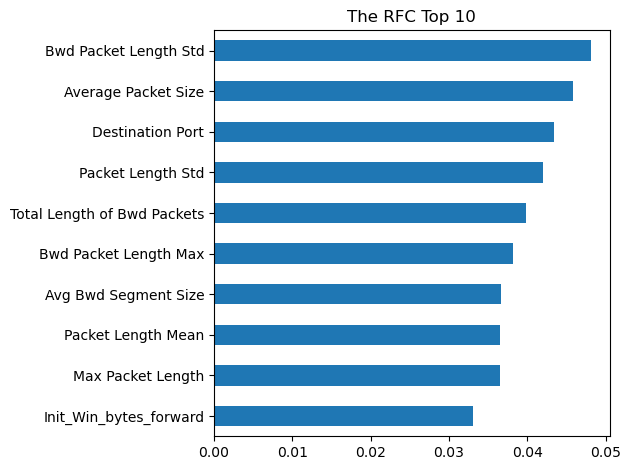

In [48]:
import matplotlib.pyplot as plt

rfc_importance = RandomForestClassifier(n_estimators = 100, random_state=1)
rfc_importance.fit(X,y)

importance = pd.Series(rfc_importance.feature_importances_, index=X.columns)
print(importance.nlargest(10))

importance.nlargest(10).sort_values().plot(kind='barh')
plt.title('The RFC Top 10')
plt.tight_layout()
plt.show()